# Assignment 2: Molecular Dynamics of n-Pentane

**6EMA02 Particle-based Simulations, 2026-2027 edition**
United-atom force field · liquid n-pentane · conformers and diffusion

## How this assignment is assessed: read this first

This notebook is both the assignment text and your report. Task cells
(like this one) are the assignment text and are marked read-only. Jupyter
enforces that; some editors (VS Code among them) do not, so simply leave
them untouched either way: hand-ins are checked against the released
notebook, and modified task cells are flagged. You write your answers in
the cells below each task and hand in this same notebook, **executed**,
together with an HTML export, your code, and the data files the notebook
loads (layout at the end of this notebook).

Your report is **not graded on its content**. Its result is determined in
the individual oral examination at the end of the quartile: the exam is a
conversation about *your* code and *your* results, with this notebook on
screen. Write it as your defence dossier: concise, bullet answers are
fine, every claim something you can stand behind. A report you never hand
in scores 0 for its weight in the final grade; a handed-in report's
result *is* your oral grade.

**AI and sources.** You may use AI assistants (ChatGPT, Claude, Copilot,
…) freely in this course, for code, analysis, and text. Declare the use
briefly in the *Sources* section below, along with any other external
sources: anything in your submission (code, text, data, results) that
your group did not produce itself. Declared sources are never penalised:
nobody grades the text of your report or the style of your code. The oral
examination assesses what *you* understand about the simulation you hand
in. Anything in your submission is fair game, and "we didn't write that
part" is not an available answer. Presenting undeclared external work as
your own is academic misconduct and is treated as such.

## Group

- **Group ID:** 5
- **Members:** Olivier Jakub Toczyski (), Thomas Dadikozyan (student ID)

## The physics: what molecular dynamics does

Molecular dynamics answers a simple question with a lot of consequences:
if we knew the force on every atom, and we integrated Newton's equations
of motion for all of them, what would the material do?

The machinery is exactly what you built in A1. Positions and velocities
evolve under

$$m_i \frac{\mathrm{d}^2 \mathbf{r}_i}{\mathrm{d}t^2} = \mathbf{F}_i =
-\nabla_i U(\mathbf{r}_1, \ldots, \mathbf{r}_N),$$

integrated with velocity-Verlet. What changes is the potential energy
$U$, and the consequences of that change reach into every part of the
program:

- **The interactions are short ranged.** Gravity reaches across the solar
  system, so A1 could afford all $N(N-1)/2$ pairs. The Lennard-Jones
  interaction is negligible beyond a few molecular diameters, so we cut
  it off and only ever look at nearby pairs. That is what the cell-linked
  list and Verlet neighbour list in the provided code are for: they turn
  an $O(N^2)$ force evaluation into $O(N)$.
- **The system is periodic.** A few thousand molecules in a box with
  walls would be almost all surface. Periodic boundary conditions with
  the minimum-image convention give a bulk liquid instead.
- **The molecules have internal structure.** Besides the non-bonded
  interactions there are bonds, angles and torsions, which is where the
  chemistry of pentane enters.
- **Temperature is a thing you control.** A thermostat lets you sample a
  constant-temperature (NVT) ensemble instead of constant energy (NVE).

Why any of this is worth doing: from the trajectory you can measure
quantities that are hard or impossible to get any other way. In this
assignment you measure two of them, each testing a different layer of the
simulation. The conformer populations test the free-energy landscape of a
single molecule, and reveal the **pentane effect**, a genuinely subtle
piece of chemistry. The mean-squared displacement gives a transport
coefficient, the self-diffusion coefficient, through the Einstein
relation

$$\left\langle |\mathbf{r}_\mathrm{cm}(t) - \mathbf{r}_\mathrm{cm}(0)|^2
\right\rangle \xrightarrow{\ t\ \text{large}\ } 6 D t .$$

## The model: a united-atom force field for n-pentane

**The molecule.** n-Pentane is
$\mathrm{CH}_3$-$\mathrm{CH}_2$-$\mathrm{CH}_2$-$\mathrm{CH}_2$-$\mathrm{CH}_3$.
We do not simulate the hydrogens. In a **united-atom** model each
$\mathrm{CH}_3$ or $\mathrm{CH}_2$ group is one interaction site with the
mass of the whole group. Two reasons: it removes two thirds of the sites,
and, more importantly, it removes the fastest motion in the system. A
C-H bond vibrates with a period of about 10 fs, which would force a time
step of roughly 0.1 fs; without hydrogens, 1 fs is enough.

Each molecule therefore has 5 sites, **4 bonds, 3 angles and 2
dihedrals** ($\phi_1$ over atoms 1-2-3-4 and $\phi_2$ over atoms
2-3-4-5). The two dihedrals share three atoms, which is what makes their
statistics *coupled* rather than independent, and that coupling is the
subject of task C2.

**State point:** density $\rho = 626\ \mathrm{kg/m^3}$ and
$T = 293$ K, which is liquid pentane at ambient conditions.

### Non-bonded: Lennard-Jones

$$U_{\mathrm{LJ}}(r) = 4\epsilon\left[\left(\frac{\sigma}{r}\right)^{12} -
\left(\frac{\sigma}{r}\right)^{6}\right] - U_{\mathrm{LJ}}(r_{\text{cut}})
\quad \text{for } r \le r_{\text{cut}},$$

and zero beyond. Use $r_\text{cut} = 14$ Å. The $r^{-6}$ term is the
attractive dispersion interaction that holds the liquid together; the
$r^{-12}$ term is the repulsion that keeps sites apart. Subtracting
$U_{\mathrm{LJ}}(r_\text{cut})$ shifts the potential to zero at the
cut-off, so that no energy jump occurs when a pair crosses it.

| Site | $\epsilon/k_B$ (K) | $\sigma$ (Å) | mass (amu) |
|------|-----|------|------|
| $\mathrm{CH}_3$ | 98.0 | 3.75 | 15.035 |
| $\mathrm{CH}_2$ | 46.0 | 3.95 | 14.027 |

Cross terms follow the Lorentz-Berthelot mixing rules,
$\sigma_{ij} = \tfrac12(\sigma_i + \sigma_j)$ and
$\epsilon_{ij} = \sqrt{\epsilon_{ii}\,\epsilon_{jj}}$.

**Exclusions.** Within a molecule, the 1-2, 1-3 and 1-4 pairs must
**not** interact through Lennard-Jones: their geometry is already fixed
by the bond, angle and torsion terms, and counting both would be double
counting. The **1-5 pair does interact**, and that single interaction,
between the two end groups, is what makes the pentane effect of task C2
appear.

### Bonded terms

$$U_{\mathrm{bond}}(r) = \tfrac12 k_b (r - r_0)^2, \qquad
r_0 = 1.54\ \text{Å}, \quad k_b/k_B = 3.19\times10^{5}\ \text{K/Å}^2,$$

$$U_{\mathrm{angle}}(\theta) = \tfrac12 k_\theta (\theta - \theta_0)^2,
\qquad \theta_0 = 114^\circ, \quad
k_\theta/k_B = 6.25\times10^{4}\ \text{K rad}^{-2}.$$

For each of the two dihedral angles, the Ryckaert-Bellemans torsion

$$U_{\mathrm{tors}}(\phi) = c_0 + c_1\cos\phi + c_2\cos^2\phi +
c_3\cos^3\phi,$$

$$c_0/k_B = 1010.0\ \text{K},\quad c_1/k_B = -2018.9\ \text{K},\quad
c_2/k_B = 136.4\ \text{K},\quad c_3/k_B = 3165.3\ \text{K}.$$

This has its global minimum at $\phi = 180^\circ$ (*trans*) and local
minima near $\pm 60^\circ$ (*gauche*), separated by barriers of several
$k_BT$. Those barriers are the reason conformer statistics converge
slowly: a molecule sits in one state for a long time and flips rarely, so
what you are sampling is a **rare event**, which task C2 asks you to
think about quantitatively.

A force field like this one is *empirical*: the functional forms are
chosen for convenience and the parameters are fitted, here to
thermodynamic data for alkanes. Nothing guarantees it reproduces a
property it was not fitted to. That is the difference between
verification (Part B: does my code implement this model correctly?) and
validation (Part C: does this model describe real pentane?).

## The code, and your working environment

The starting code is `MD_student_v7.0.0.zip` under Files ▸ Code. It is a
working Lennard-Jones molecular dynamics program: your job is to extend
it into a pentane simulator. Unpacking it gives you a folder
`MD_student_v7.0.0`; rename that to `code/` in your working directory, so
that the paths in this notebook and in the hand-in layout line up.

**The files.** `main.c` holds the whole control flow and is the place to
start reading. Then: `constants.h` (compile-time constants),
`structs.h` (all data types), `memory.c` (allocation and freeing),
`setparameters.c` (**the only place run configuration lives**: there are
no input files, you recompile to change a run), `random.c`,
`initialise.c` (initial positions, velocities, topology), `nbrlist.c`
(cell-linked list and Verlet neighbour list), `forces.c` (your main work
site), `dynamics.c` (the velocity-Verlet halves, boundary conditions,
thermostat), `fileoutput.c` (`.pdb` trajectories and restart files), and
`force_test.c` (the finite-difference force and virial checker you will
use in B3 and B5).

**The task list.** Open `html/index.html` from the zip: the Doxygen
documentation of the code has a generated *todo list* with every
`\todo` marker you must fill in. Treat it as the checklist for Part B.

**Build and run** (Linux and macOS; on Windows use MSYS2 or the provided
VS Code tasks):

```
gcc -O3 *.c -o md -lm                      # production
gcc -g -Wall -Wextra *.c -o md_debug -lm   # debugging
./md > run.csv
```

**House rules when extending.** New functions get a prototype in the
matching `.h`. New per-particle arrays are added to a struct in
`structs.h`, allocated in `alloc_memory` and freed in `free_memory`.
Internal units are the reduced units of task A1, not SI.

**Visualisation.** The code writes `.pdb` trajectories; open them in
OVITO (ovito.org). Look at your system early and often: most bugs in
this assignment are visible before they are measurable.

**Python environment.** The same `pbs-env` you set up for A1, from
`requirements.txt` (Files ▸ Assignments); the Canvas page *Working on the
assignments* has the details. The helper scripts are unchanged:
`nb2html.py` writes the HTML you hand in, `check_my_submission.py`
checks your zip before you submit it.

## Code map: fill in as you go

The examiner uses this table in the oral to jump straight to your code,
so **make the entries clickable links**: a markdown link with a path
relative to this notebook, for example

```
| B4 bonded forces | [`calculate_forces_bond`](code/forces.c) | [nve_molecule.csv](data/nve_molecule.csv) |
```

Relative paths only (`code/…`, `data/…`); everything you link to must be
inside the zip you hand in. `check_my_submission.py` verifies this.

| Task | File / function(s) | Data files |
|------|--------------------|------------|
| B1 I/O | [`main`](code/main.c) | [CSV check](data/b1_output_check.csv) |
| B2 types + LJ | [`initialise_types`, `initialise_velocities`](code/initialise.c), [`update_velocities_half_dt`](code/dynamics.c), [`calculate_forces_nb`](code/forces.c) | [force check](data/b3_forcecheck.txt), [NVE 1 fs](data/b3_nve_1fs.csv), [NVE 0.5 fs](data/b3_nve_05fs.csv), [NVT continuation](data/b3_equil_long.csv) |
| B4 bonded forces | … | … |
| B6 initialization | … | … |
| B8 thermostat | … | … |
| C1 conformer analysis | … | … |
| C2 MSD and diffusion | … | … |

## Sources

**AI tools used:** OpenAI Codex (B1–B3 assistance).
**Used for:** reviewing the existing type-dependent masses and LJ implementation,
analysing saved CSV and force-check output, and drafting B1–B3 explanations and plots.
**Other external sources:** course-supplied MD starter code and assignment text.
Add any other sources or earlier AI assistance used by the group.
**Parts with substantial AI-assisted content:** B1–B3 report text and
[`analyse_b123.py`](code/analyse_b123.py), also included in the notebook below.
**Verification performed in this session:** compiled the C code and executed the
analysis against the saved data, including numerical CSV consistency checks.
The group still needs to review these explanations and complete the equilibrium test.


## Build & run log

- Review on 2026-09-29, Windows with MSYS2 GCC: from the notebook directory,
  `gcc -O3 -Wall -Wextra code/*.c -o md_b123_check.exe -lm` succeeded
  (about 2 s). Warnings include unfinished bonded routines and the existing
  `%lu`/`size_t` format in the XYZ writer.
- The analysis below was executed using the existing `../pbs-env` Python
  environment. All plotted simulation data already existed before this review;
  no new production trajectory was generated in this session.
- Saved NVE output spans 50 ps: 50,000 steps at 1 fs and 100,000 at 0.5 fs,
  sampled every 10 and 20 steps respectively. These step counts and intervals
  are verified from the CSV files. The exact historical build commands, wall
  times and parameter snapshots were not saved here; they must not be invented.
- For future runs: edit `code/setparameters.c`, then from `code/` run
  `gcc -O3 *.c -o md -lm` and `./md > ../data/NEW_RUN.csv`
  (PowerShell: `./md.exe | Out-File -Encoding utf8 ../data/NEW_RUN.csv`).
  Use a new output name and archive the parameter settings for each run.
  Restart and trajectory paths in the current configuration are relative to `code/`.


## Part A: Modeling

*In the oral you should be able to:* state your unit system and convert
any quantity in this notebook to SI; derive each bonded force from its
potential; explain why the four torsion forces sum to zero and exert no
net torque.

### A1) Units

It is common practice to introduce non-standard units in simulations. In
your code, use Kelvin for the energy scale (that is, the energy unit is
$k_B \times 1$ K), Å for distances, and atomic mass units (amu) for
masses. The time unit follows from these.

Deliver: the derivation of the time unit, its value in SI, and the time
step of 1 fs expressed in internal units. State also the internal-unit
values you will use for $\epsilon$, $\sigma$, $k_b$ and $k_\theta$, and
one sanity check that your conversion is right (for example, the thermal
velocity of a $\mathrm{CH}_2$ site at 293 K, in both unit systems).

The chosen base units are

$$
E_0=k_B(1\ \mathrm{K})=1.380649\times10^{-23}\ \mathrm{J},
\qquad
L_0=1\ \mathrm{\AA}=10^{-10}\ \mathrm{m},
\qquad
M_0=1\ \mathrm{amu}=1.66054\times10^{-27}\ \mathrm{kg}.
$$

A quantity in internal units is its physical value divided by the
corresponding unit scale. Superscript $*$ denotes an internal-unit value.

**Time unit and timestep**

Since energy has dimensions $ML^2/t^2$, the unit scales satisfy

$$
E_0=\frac{M_0L_0^2}{t_0^2}.
$$

Therefore,

$$
t_0=\sqrt{\frac{M_0L_0^2}{E_0}}
=\sqrt{
\frac{(1.66054\times10^{-27})(10^{-10})^2}
{1.380649\times10^{-23}}
}
\approx1.0967\times10^{-12}\ \mathrm{s}
=1.0967\ \mathrm{ps}.
$$

The required timestep of $1\ \mathrm{fs}$ is therefore

$$
\Delta t^*=\frac{\Delta t}{t_0}
=\frac{10^{-15}}{1.0967\times10^{-12}}
\approx9.1184\times10^{-4}.
$$

**Force-field parameters in internal units**

The Lennard-Jones energy parameter is expressed as
$\epsilon^*=\epsilon/E_0$. Since the supplied values are
$\epsilon/k_B$ in Kelvin, their numerical values can be used directly.
Similarly, distances given in angstroms can be used directly.

| Site type | $\epsilon^*$ | $\sigma^*$ | $m^*$ |
|-----------|-------------:|-----------:|------:|
| $\mathrm{CH}_3$ | 98.0 | 3.75 | 15.035 |
| $\mathrm{CH}_2$ | 46.0 | 3.95 | 14.027 |

For a mixed $\mathrm{CH}_3$–$\mathrm{CH}_2$ pair, the
Lorentz–Berthelot rules give

$$
\epsilon_{32}^*=\sqrt{98.0\times46.0}\approx67.1416,
\qquad
\sigma_{32}^*=\frac{3.75+3.95}{2}=3.85.
$$

For the bond potential, the force constant has dimensions of energy
per length squared, so

$$
k_b^*=\frac{k_bL_0^2}{E_0}=3.19\times10^5.
$$

For the angle potential, angles are evaluated in radians, giving

$$
k_\theta^*=\frac{k_\theta}{E_0}=6.25\times10^4
\quad\text{when the angular displacement is in radians}.
$$

The equilibrium values are

$$
r_0^*=1.54,
\qquad
\theta_0=114^\circ=\frac{114\pi}{180}\approx1.98968\ \mathrm{rad}.
$$

The Lennard-Jones cut-off is $r_{\mathrm{cut}}^*=14$.

**Sanity check: thermal speed of a CH2 site at 293 K**

We use the three-dimensional root-mean-square speed,

$$
v_{\mathrm{rms}}=\sqrt{\langle v_x^2+v_y^2+v_z^2\rangle}
=\sqrt{\frac{3k_BT}{m}}.
$$

In SI units, the site mass is

$$
m=14.027(1.66054\times10^{-27})
\approx2.32924\times10^{-26}\ \mathrm{kg}.
$$

Thus,

$$
v_{\mathrm{rms}}
=\sqrt{
\frac{3(1.380649\times10^{-23})(293)}
{2.32924\times10^{-26}}
}
\approx721.8\ \mathrm{m\,s^{-1}}.
$$

In internal units, $k_BT/E_0=293$ and $m^*=14.027$, so

$$
v_{\mathrm{rms}}^*
=\sqrt{\frac{3(293)}{14.027}}
\approx7.9161.
$$

The velocity unit is

$$
v_0=\frac{L_0}{t_0}
=\frac{10^{-10}}{1.0967\times10^{-12}}
\approx91.184\ \mathrm{m\,s^{-1}}.
$$

Converting the internal speed back to SI gives

$$
v_{\mathrm{rms}}=v_{\mathrm{rms}}^*v_0
\approx7.9161(91.184)
\approx721.8\ \mathrm{m\,s^{-1}},
$$

which agrees with the direct SI calculation.

### A2) Bonded forces

From the expressions for the bond, angle, and torsion potentials, derive
the corresponding forces. Express them in terms of the bond vectors
$\mathbf{r}_{ij}$, $\mathbf{r}_{kj}$, and $\mathbf{r}_{kl}$ as defined in
`forces.c`.

Deliver, for each of the three terms: the force on every participating
atom, and one sentence on how the expression behaves in an obvious limit
(for instance at the potential minimum). State explicitly why the four
torsion forces sum to zero and carry no net torque, and describe the
numerical test that would confirm both properties on your own
implementation.

The force on an atom is the negative gradient of the potential energy:

$$
\boxed{\mathbf F_s=-\nabla_{\mathbf r_s}U}.
$$

This means that the force acts towards decreasing energy. We apply the
chain rule to connect changes in atomic positions to changes in bond
length, bond angle, or torsion angle.

Following `forces.c`, the bond vectors are

$$
\mathbf r_{ij}=\mathbf r_i-\mathbf r_j,\qquad
\mathbf r_{kj}=\mathbf r_k-\mathbf r_j,\qquad
\mathbf r_{kl}=\mathbf r_k-\mathbf r_l.
$$

These point from $j$ to $i$, from $j$ to $k$, and from $l$ to $k$,
respectively. The code applies the minimum-image convention to them.
All forces below are contributions from one interaction and must be
added to the total forces on the participating atoms.

### 1. Bond-stretch forces

**Step 1: Describe the bond.**

Let

$$
\mathbf a=\mathbf r_{ij},\qquad r=|\mathbf a|.
$$

The bond potential is

$$
U_b=\frac12k_b(r-r_0)^2.
$$

It penalises both stretching and compression relative to the preferred
bond length $r_0$.

**Step 2: Differentiate the energy with respect to bond length.**

$$
\frac{\mathrm dU_b}{\mathrm dr}=k_b(r-r_0).
$$

**Step 3: Convert this into a force vector.**

The unit vector $\mathbf a/r$ points from $j$ towards $i$. Since

$$
\nabla_{\mathbf r_i}r=\frac{\mathbf a}{r},
$$

the chain rule gives

$$
\boxed{
\mathbf F_i
=-\frac{\mathrm dU_b}{\mathrm dr}\nabla_{\mathbf r_i}r
=-k_b(r-r_0)\frac{\mathbf a}{r}
}.
$$

The force on the other atom is opposite:

$$
\boxed{\mathbf F_j=-\mathbf F_i}.
$$

**Physical check:** at $r=r_0$, both forces vanish. If the bond is
stretched, the forces pull the atoms together; if compressed, they
push them apart.

### 2. Angle-bend forces

**Step 1: Express the angle using the bond vectors.**

For the angle $i$–$j$–$k$, the central atom is $j$. Define

$$
\mathbf a=\mathbf r_{ij},\qquad
\mathbf b=\mathbf r_{kj},\qquad
a=|\mathbf a|,\qquad b=|\mathbf b|.
$$

The dot-product identity gives

$$
q=\cos\theta=\frac{\mathbf a\cdot\mathbf b}{ab},
\qquad \theta=\arccos q.
$$

The angle potential is

$$
U_\theta=\frac12k_\theta(\theta-\theta_0)^2.
$$

**Step 2: Follow the chain of dependencies.**

Moving an atom changes the bond vectors, which changes $q$, then
$\theta$, and finally the energy. Therefore,

$$
\mathbf F_i
=-\frac{\mathrm dU_\theta}{\mathrm d\theta}
  \frac{\mathrm d\theta}{\mathrm dq}
  \nabla_{\mathbf r_i}q.
$$

The first two derivatives are

$$
\frac{\mathrm dU_\theta}{\mathrm d\theta}
=k_\theta(\theta-\theta_0),
\qquad
\frac{\mathrm d\theta}{\mathrm dq}
=-\frac1{\sin\theta}.
$$

**Step 3: Differentiate the cosine with respect to position.**

Moving atom $i$ changes $\mathbf a$ but leaves $\mathbf b$ fixed.
Using the product rule on $q=(\mathbf a\cdot\mathbf b)/(ab)$,

$$
\nabla_{\mathbf r_i}q
=\frac{\mathbf b}{ab}
-\frac{(\mathbf a\cdot\mathbf b)\mathbf a}{a^3b}
=\frac{\mathbf b}{ab}-q\frac{\mathbf a}{a^2}.
$$

Similarly, moving atom $k$ gives

$$
\nabla_{\mathbf r_k}q
=\frac{\mathbf a}{ab}-q\frac{\mathbf b}{b^2}.
$$

**Step 4: Combine the derivatives.**

The minus sign in the force definition cancels the minus sign from
differentiating $\arccos q$:

$$
\boxed{
\mathbf F_i=
\frac{k_\theta(\theta-\theta_0)}{\sin\theta}
\left(\frac{\mathbf b}{ab}
-\cos\theta\frac{\mathbf a}{a^2}\right)
},
$$

$$
\boxed{
\mathbf F_k=
\frac{k_\theta(\theta-\theta_0)}{\sin\theta}
\left(\frac{\mathbf a}{ab}
-\cos\theta\frac{\mathbf b}{b^2}\right)
}.
$$

Moving the central atom $j$ changes both bond vectors with a minus
sign, because $\mathbf a=\mathbf r_i-\mathbf r_j$ and
$\mathbf b=\mathbf r_k-\mathbf r_j$. Hence,

$$
\boxed{\mathbf F_j=-\mathbf F_i-\mathbf F_k}.
$$

**Physical check:** at $\theta=\theta_0$, all three forces vanish.
The force on each outer atom is perpendicular to its corresponding
bond vector, consistent with bending the angle. Angles must be
evaluated in radians; the formulas assume nonzero bond lengths and
$0<\theta<\pi$.

### 3. Dihedral-torsion forces

**Step 1: Describe the two planes defining the torsion.**

For four connected atoms $i$–$j$–$k$–$l$, the torsion describes the
relative orientation of the planes $i$–$j$–$k$ and $j$–$k$–$l$.

Define

$$
\mathbf a=\mathbf r_{ij},\qquad
\mathbf b=\mathbf r_{kj},\qquad
\mathbf c=\mathbf r_{kl}.
$$

Cross products give vectors perpendicular to these planes:

$$
\mathbf n=\mathbf a\times\mathbf b,\qquad
\mathbf m=\mathbf b\times\mathbf c,
\qquad N=|\mathbf n|,\qquad M=|\mathbf m|.
$$

The cosine of the torsion is

$$
q=\cos\phi=\frac{\mathbf n\cdot\mathbf m}{NM}.
$$

With these vector directions, a trans configuration gives opposite
normals, so $q=-1$ and $\phi=\pi$, as required by the assignment.

**Step 2: Differentiate the torsion potential.**

Since the potential depends only on $\cos\phi$, we can differentiate
directly with respect to $q$:

$$
U_\phi=c_0+c_1q+c_2q^2+c_3q^3.
$$

Define

$$
H=\frac{\mathrm dU_\phi}{\mathrm dq}
=c_1+2c_2q+3c_3q^2.
$$

The force on any participating atom is therefore

$$
\mathbf F_s=-H\nabla_{\mathbf r_s}q.
$$

The remaining task is to find how $q$ changes when each atom moves.

**Step 3: Differentiate with respect to the plane normals.**

The normalized dot product has the same mathematical form as in the
angle derivation. Therefore,

$$
\mathbf A=\nabla_{\mathbf n}q
=\frac{\mathbf m}{NM}-q\frac{\mathbf n}{N^2},
$$

$$
\mathbf B=\nabla_{\mathbf m}q
=\frac{\mathbf n}{NM}-q\frac{\mathbf m}{M^2}.
$$

Here $\mathbf A$ and $\mathbf B$ are intermediate derivatives, not
atomic forces.

**Step 4: Convert derivatives of the normals into derivatives of
the bond vectors.**

Small changes in the normals satisfy

$$
\mathrm d\mathbf n
=\mathrm d\mathbf a\times\mathbf b
+\mathbf a\times\mathrm d\mathbf b,
$$

$$
\mathrm d\mathbf m
=\mathrm d\mathbf b\times\mathbf c
+\mathbf b\times\mathrm d\mathbf c.
$$

Substituting into

$$
\mathrm dq=\mathbf A\cdot\mathrm d\mathbf n
+\mathbf B\cdot\mathrm d\mathbf m
$$

and rearranging scalar triple products gives

$$
\mathrm dq
=\mathbf g_a\cdot\mathrm d\mathbf a
+\mathbf g_b\cdot\mathrm d\mathbf b
+\mathbf g_c\cdot\mathrm d\mathbf c,
$$

where

$$
\mathbf g_a=\mathbf b\times\mathbf A,
$$

$$
\mathbf g_b=\mathbf A\times\mathbf a+\mathbf c\times\mathbf B,
$$

$$
\mathbf g_c=\mathbf B\times\mathbf b.
$$

These vectors are the gradients of $q$ with respect to
$\mathbf a$, $\mathbf b$, and $\mathbf c$.

**Step 5: Assign the derivatives to the four atoms.**

The signs follow directly from the definitions of the bond vectors:

| Atom moved | Bond-vector changes | Gradient of $q$ |
|---|---|---|
| $i$ | $\mathbf a$ changes positively | $\mathbf g_a$ |
| $j$ | $\mathbf a$ and $\mathbf b$ change negatively | $-\mathbf g_a-\mathbf g_b$ |
| $k$ | $\mathbf b$ and $\mathbf c$ change positively | $\mathbf g_b+\mathbf g_c$ |
| $l$ | $\mathbf c$ changes negatively | $-\mathbf g_c$ |

Multiplying each gradient by $-H$ gives

$$
\boxed{\mathbf F_i=-H\mathbf g_a},
$$

$$
\boxed{\mathbf F_j=H(\mathbf g_a+\mathbf g_b)},
$$

$$
\boxed{\mathbf F_k=-H(\mathbf g_b+\mathbf g_c)},
$$

$$
\boxed{\mathbf F_l=H\mathbf g_c}.
$$

**Physical check:** at trans, the opposite unit normals give
$\mathbf A=\mathbf B=\mathbf0$, so all torsion forces vanish.
At an interior gauche minimum, $H=0$, also giving zero forces.
The formulas require $N,M\ne0$ because a collinear atom triplet
does not define a torsion plane.

### 4. Why the torsion produces no net force or net torque

**Net force**

Adding the four force expressions gives

$$
\sum_s\mathbf F_s
=-H\mathbf g_a
+H(\mathbf g_a+\mathbf g_b)
-H(\mathbf g_b+\mathbf g_c)
+H\mathbf g_c
=\mathbf0.
$$

Physically, translating all four atoms equally does not change the
torsion or its energy. This translational invariance implies zero
net force.

**Net torque**

Rotating the entire four-atom group rigidly also leaves its torsion
and energy unchanged.

For a small rotation $\delta\boldsymbol\omega$ about an origin
$\mathbf R$,

$$
\delta\mathbf r_s
=\delta\boldsymbol\omega\times(\mathbf r_s-\mathbf R).
$$

The energy change is

$$
\delta U
=-\sum_s\mathbf F_s\cdot\delta\mathbf r_s
=-\delta\boldsymbol\omega\cdot
\sum_s(\mathbf r_s-\mathbf R)\times\mathbf F_s.
$$

Since the energy change is zero for any rigid rotation,

$$
\boxed{
\sum_s(\mathbf r_s-\mathbf R)\times\mathbf F_s=\mathbf0
}.
$$

The torsion can therefore rotate parts of the molecule relative to
each other without exerting a net torque on the complete group.

### 5. Numerical tests on the implementation

We will test several noncollinear configurations from a thermalised
molecule, rather than only an equilibrium geometry where forces vanish.

For each isolated torsion interaction, we will calculate and report

$$
\mathbf F_{\mathrm{net}}=\sum_s\mathbf F_s,
\qquad
\boldsymbol\tau_{\mathrm{net}}
=\sum_s(\mathbf r_s-\mathbf R)\times\mathbf F_s.
$$

The torque calculation must use a consistent unwrapped geometry.
Taking atom $j$ as the origin, suitable positions are

$$
\mathbf x_j=\mathbf0,\qquad
\mathbf x_i=\mathbf a,\qquad
\mathbf x_k=\mathbf b,\qquad
\mathbf x_l=\mathbf b-\mathbf c.
$$

Both residuals should be zero within floating-point round-off.
To judge their size relative to the individual contributions, we
will also calculate

$$
\eta_F=\frac{|\mathbf F_{\mathrm{net}}|}{\sum_s|\mathbf F_s|},
\qquad
\eta_\tau=
\frac{|\boldsymbol\tau_{\mathrm{net}}|}
{\sum_s|\mathbf x_s|\,|\mathbf F_s|},
$$

using configurations with nonzero denominators.

Finally, for each bonded potential separately, we will compare the
analytical forces with central finite differences:

$$
F_{s\alpha}^{\mathrm{FD}}
=-\frac{
U(\mathbf r_s+\delta\mathbf e_\alpha)
-U(\mathbf r_s-\delta\mathbf e_\alpha)
}{2\delta}.
$$

Here one atom is displaced slightly along one Cartesian direction,
while all other positions remain fixed. Several displacement sizes
will be tested to balance truncation and round-off errors.

The net-force and net-torque checks test conservation properties.
The finite-difference test additionally checks whether the forces
are the negative gradient of the implemented energy.

## Part B: Implementation and testing

*In the oral you should be able to:* walk through any force routine you
wrote and justify it line by line; explain what the finite-difference
force test proves and what it cannot catch; explain why the test must run
from an equilibrated configuration; explain why energy conservation is
tested in NVE and how the drift should scale with the timestep.

Throughout Part B, every claim of correctness needs a number: a relative
error, a drift, a tolerance. "It looks fine" is not a verification.

### B1) I/O

Output diagnostic data (the energies and the temperature) to CSV every
few steps, either by redirecting stdout or by writing a file. Every plot
in this notebook loads from `data/`.

Diagnostic output is written by [`main`](code/main.c) as CSV on standard
output, every `num_dt_output` steps, after both velocity-Verlet half updates.
Thus $E_\mathrm{pot}$ and $E_\mathrm{kin}$ refer to the same full timestep.
For NVT, kinetic energy is recalculated after velocity scaling.

The current columns are step, internal time, potential energy, kinetic energy,
total energy, total temperature, and the two site-type temperatures. The older
[`b1_output_check.csv`](data/b1_output_check.csv) contains the first six columns.
Its 10 rows are separated by 10 steps. The analysis below verifies finite
values, $E_\mathrm{tot}=E_\mathrm{pot}+E_\mathrm{kin}$ to $10^{-8}$ internal energy
units and the temperature identity to $10^{-12}$ K, and prints the actual residuals.

For $N=2000$ flexible sites with centre-of-mass momentum removed,

$$T=\frac{2E_\mathrm{kin}}{3N-3}.$$

Energy is in $k_B\,\mathrm{K}$, distance in Å and time in
$t_0=1.096687535$ ps; the numerical temperature is in Kelvin.
The older B1 file is only a starter-model I/O test, not a 293 K pentane run.
All plots below read saved files from `data/`.


### B2) Particle types and non-bonded forces

Implement particle typing ($\mathrm{CH}_3$ and $\mathrm{CH}_2$) using the
`type` array in `Vectors`: extend `initialise_types`. Take the
type-dependent masses into account in the velocity updates and in the
kinetic energy. Implement the LJ forces with Lorentz-Berthelot parameters
selected per pair type.

### B3) Test the non-bonded forces

Verify correctness with the provided finite-difference checker
(`force_test.c`) **from an equilibrated configuration**, and demonstrate
long-time energy conservation in NVE at the target density.

Deliver:

- a **table** of the finite-difference test: the largest relative error
  over the particles, for the force and for the virial, with the
  displacement step you used and the tolerance you accepted;
- a **figure** of total, kinetic and potential energy against time for an
  NVE run at the target density;
- a **number**: the relative energy drift per unit time, and what it
  becomes when you halve the time step. State the scaling you expected
  and whether you observed it. Separate the bounded oscillation of
  $E_\mathrm{tot}$ from any systematic slope before you quote a scaling:
  they need not behave the same way, and only one of them is the
  integrator's own error.
- a **check on your masses**: the temperature implied by each site type
  separately, from the mean square velocity of its own sites, next to the
  set point. The two types have different masses but must give the same
  temperature. Nothing else in this assignment tests that you used the
  right mass for the right site: the force test never touches masses, and
  energy is conserved just as happily with the wrong ones. If your two
  numbers disagree, say whether that is your typing, your time step or
  your equilibration, and show the run that decides it.

Then explain, in two or three sentences, why running this test from the
initial lattice instead of an equilibrated configuration would hide
errors.

*On the tolerance:* do not pick one out of the air. Estimate the accuracy
the check itself can reach. It differences two nearly equal potential
energies, so it loses digits in proportion to how large that energy is
compared with the change a displacement of $\delta$ produces, and the
resulting floor is absolute, which means it hurts your smallest forces
most. Work out roughly where that floor sits for your system and accept a
tolerance a little above it.

### B2: particle types, masses and pair forces

`initialise_types` assigns each block of five sites the sequence
CH3–CH2–CH2–CH2–CH3. For 2000 sites this gives 800 CH3 sites
($m=15.035$ amu) and 1200 CH2 sites ($m=14.027$ amu).
The same type selects the mass in both velocity half updates,
$\Delta\mathbf v_i=\mathbf F_i\Delta t/(2m_i)$, and in
$E_\mathrm{kin}=\sum_i m_i|\mathbf v_i|^2/2$.
Initial Gaussian velocity components have variance $T/m_i$; subtracting the
mass-weighted centre-of-mass velocity removes total momentum.

The pair parameters used by `calculate_forces_nb` are:

| Pair | $\epsilon/k_B$ (K) | $\sigma$ (Å) |
|---|---:|---:|
| CH3–CH3 | 98 | 3.75 |
| CH3–CH2 | 67.1416 | 3.85 |
| CH2–CH2 | 46 | 3.95 |

With $\mathbf r_{ij}=\mathbf r_i-\mathbf r_j$ under the minimum-image convention,

$$\mathbf F_i=\frac{24\epsilon_{ij}}{r^2}
\left[2(\sigma_{ij}/r)^{12}-(\sigma_{ij}/r)^6\right]\mathbf r_{ij},
\qquad \mathbf F_j=-\mathbf F_i.$$

The pair-specific energy at $r_c=14$ Å is subtracted from each interacting
pair's energy. This constant does not change the force inside the cut-off.
The virial accumulator adds $\mathbf r_{ij}\cdot\mathbf F_i$ per pair before
division by $3V$. The existing mass and LJ expressions agree with these formulas.

**Scope:** there are currently no bonds in `initialise_bond_connectivity`,
and the bonded force routines are unfinished. These B3 runs test an **unbonded
binary LJ system**, with pentane's 2:3 type ratio and mass density, not liquid
pentane yet. Molecular exclusions become active only after connectivity is
implemented. The total mass gives $L=42.46121$ Å at
$\rho=626\ \mathrm{kg\,m^{-3}}$, satisfying $r_c<L/2$.

### B3: force and virial checks

The saved log tests all 2000 particles (none reported below resolution):

| Check | Finite-difference step | Largest reported relative error | Accepted tolerance |
|---|---|---:|---:|
| Force vector, maximum over sites | $\delta=10^{-6}$ Å | $7.39444\times10^{-6}$ | $10^{-4}$ |
| Global virial | scaling $h=10^{-6}$ | $4.57505\times10^{-11}$ | $10^{-8}$ |

The virial is one global check, not a per-particle maximum. The checker divides
the force error norm by the larger analytical/FD force norm; its virial
normalisation is $\max(|W_\mathrm{FD}|,|U_+|)$.

**Tolerance estimate.** Double precision has $\epsilon_\mathrm{mach}\simeq
2.22\times10^{-16}$. Using the saved early NVT endpoint as the energy scale,
$|U|\simeq1.26\times10^6$, the checker's estimate
$16\epsilon_\mathrm{mach}|U|/\delta$ is about $4.48\times10^{-3}$ internal
force units. The smallest logged force norm is about 90.2, giving a relative
resolution estimate of $5.0\times10^{-5}$; $10^{-4}$ is a conservative tolerance
just above this estimate. This is an order-of-magnitude round-off estimate,
not a rigorous bound on accumulation error. For the virial,
$16\epsilon_\mathrm{mach}|U|/(h|W|)\simeq1.1\times10^{-10}$ with
$|W|\simeq4.14\times10^7$; $10^{-8}$ allows additional summation/truncation error.
The old log does not identify its restart or parameter snapshot, so it cannot
establish the provenance or equilibration of the tested state. Repeat and
record that information for the final verification.

### B3: NVE energy conservation and timestep dependence

The following analysis fits $E(t)=a+bt$ over each complete 50 ps trace and
defines relative drift as $b/|\overline E|$, per ps. It also reports the RMS
residual **after subtracting the fitted slope**, so oscillation and drift
are not confused.

| Timestep | Relative drift (ps$^{-1}$) | Detrended RMS ($k_B$ K) |
|---|---:|---:|
| 1 fs | $-4.8970\times10^{-8}$ | 4.15875 |
| 0.5 fs | $-9.5157\times10^{-9}$ | 1.01997 |

For a smooth potential, velocity-Verlet has bounded energy error of order
$\Delta t^2$, so halving the timestep should reduce its amplitude about fourfold.
The measured RMS ratio is **4.077**, consistent with this expectation.
The slope magnitude drops by **5.146**, but a fitted slope from two finite,
chaotic trajectories is not proof of a universal drift scaling. Velocity-Verlet's
characteristic error is the bounded oscillation, not secular energy loss.
Here the energy-shifted LJ potential also has a force discontinuity at the
cut-off; crossings can add errors that are not described by the smooth-potential
argument. The plots zoom in on total energy as well as displaying all three energies.

### B3: mass check and the actual problem with these runs

For each type $s$, the diagnostic is
$T_s=m_s\langle |\mathbf v|^2\rangle_s/3$.
Means over the last 25 ps are:

| Run | CH3 (K) | CH2 (K) | Set point (K) |
|---|---:|---:|---:|
| NVE, 1 fs | 312.214 | 311.271 | 293 |
| NVE, 0.5 fs | 310.532 | 310.340 | 293 |
| Longer NVT continuation, 1 fs | 292.988 | 292.667 | 293 |

The two masses produce similar temperatures; both NVE types heat together.
Halving the timestep does not remove this heating, whereas the longer NVT
continuation brings both types near the set point. Combined with the code review,
this supports correct mass handling and points to **incomplete equilibration**.
NVE has no active temperature set point: falling potential energy becomes
kinetic energy while the total stays nearly constant.

The per-type diagnostic uses $3N_s$ in its denominator. Removing total momentum
slightly changes its finite-system expectation to
$T_s=T(1-m_s/M_\mathrm{total})$, about 292.847 K for CH3 and 292.858 K for CH2
at $T=293$ K. This roughly 0.15 K correction is smaller than the observed
sampling variations. The code below reports descriptive block standard errors;
these are not equilibrium confidence intervals for a drifting trajectory.

**Equilibration has not yet been demonstrated.** The mean potential energy in
successive 10 ps blocks of the longer NVT run falls from approximately 964261
to 914478, 864777, 859820 and 852644 internal units. A thermostat keeping $T$
near 293 K does not establish structural stationarity. These saved runs give
useful non-bonded verification, but do not yet meet B3's requirement to start
the final tests from an equilibrated configuration.

To finish that requirement, continue NVT from `b3_equil_long_restart.dat`
into **new** output files until potential-energy and both type-temperature
block means show no systematic trend over several blocks. Save this state,
run `force_test = 1` from it, and start matched-duration NVE runs at 1 fs and
0.5 fs from that same restart (`is_NVT = 0`), keeping the density fixed.
Record the parameters, commands and runtime for each run; update these tables
with the new measurements. Do not just run the current settings unchanged:
they restart from the older `b3_equil_extra_restart.dat`.

An initial lattice can make forces cancel by symmetry and samples only a small
set of separations, concealing errors that appear in irregular configurations.
A thermalised configuration tests nonzero forces and diverse local environments;
the finite-difference check still cannot detect wrong masses or a potential and
force that consistently implement the same wrong model.


B1: 10 finite rows, spacing 10 steps; max |E-K-U| = 1e-11; max temperature identity error = 1.22e-15 K


,check,FD step,relative error,accepted tolerance,within tolerance
0,"max force error, 2000 sites",delta = 1e-6 angstrom,7.394440e-06,1.000000e-04,True
1,global virial error,h = 1e-6 (dimensionless),4.575050e-11,1.000000e-08,True


Force noise estimate: 0.00448 internal force units; smallest |F| = 90.2; relative floor ~ 4.97e-05.


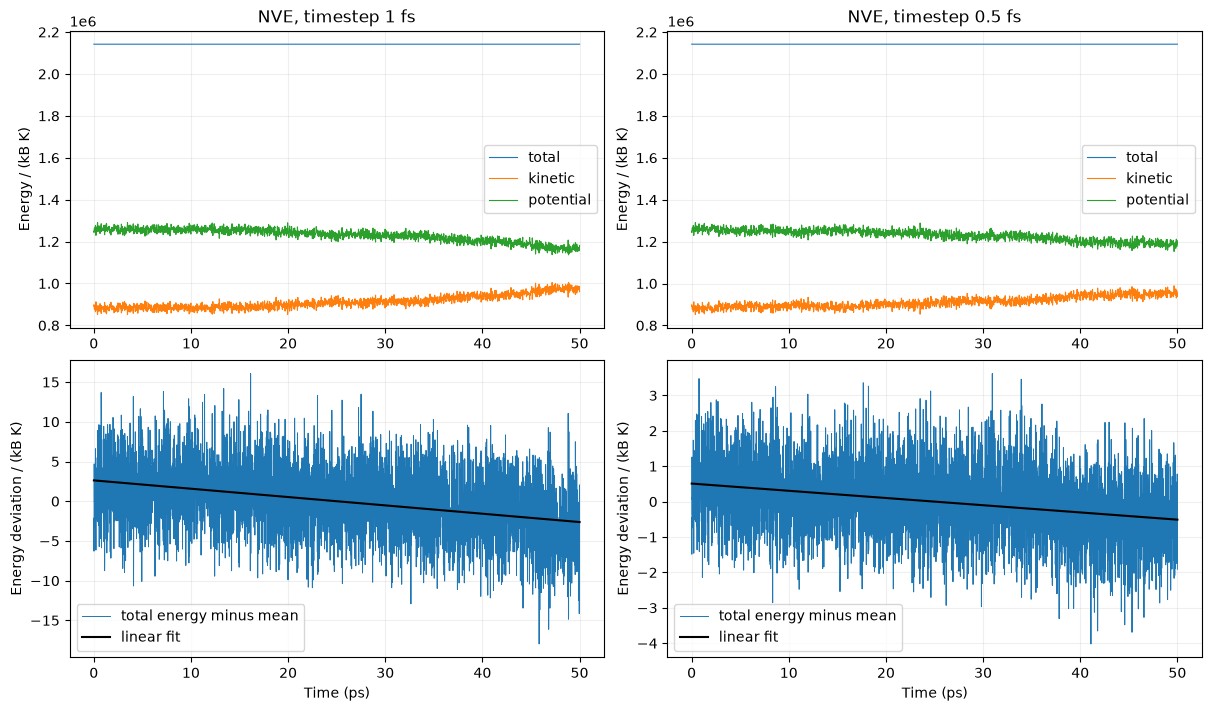

,dt (fs),duration (ps),slope (internal energy/ps),relative drift (1/ps),detrended RMS (internal energy)
0,1.0,49.999959,-0.104898,-4.896998e-08,4.158751
1,0.5,49.999959,-0.020384,-9.515750e-09,1.019974


1 fs / 0.5 fs ratios: |slope| = 5.146; detrended RMS = 4.077


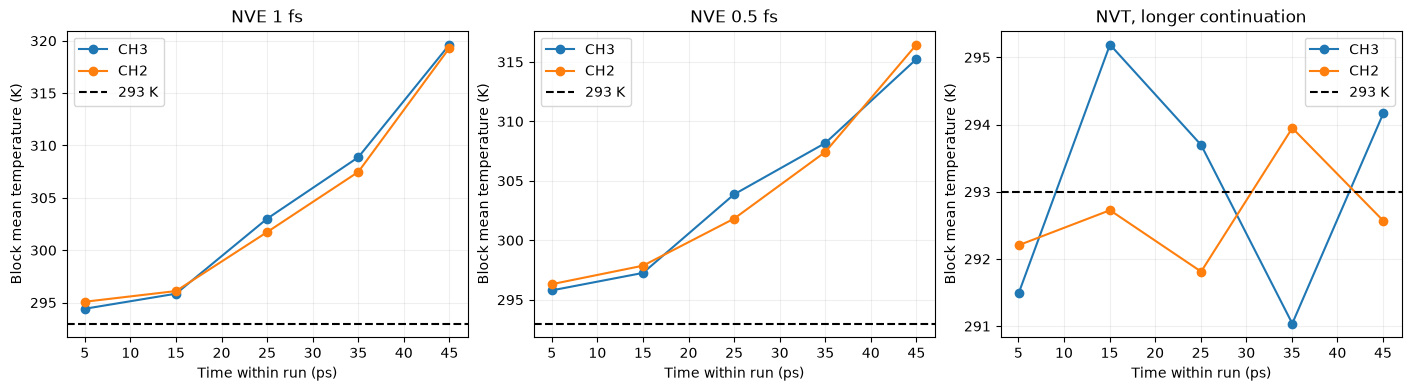

,run,type,"mean, last half (K)",5-block SE (K),set point (K)
0,NVE 1 fs,CH3,312.214180,3.738181,293.0
1,NVE 1 fs,CH2,311.271369,3.708475,293.0
2,NVE 0.5 fs,CH3,310.532290,2.156982,293.0
3,NVE 0.5 fs,CH2,310.339877,2.678987,293.0
4,"NVT, longer continuation",CH3,292.988124,0.872806,293.0
5,"NVT, longer continuation",CH2,292.666915,0.672540,293.0


,NVT time block (ps),mean potential energy (internal)
0,0-10,964261.202256
1,10-20,914478.080594
2,20-30,864776.532060
3,30-40,859820.362534
4,40-50,852644.258082


Conclusion: good force/energy checks, but continued structural relaxation; equilibrium is not yet demonstrated.


In [1]:
"""B1-B3 analysis. Run from the notebook directory; all inputs are in data/."""
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

time_unit_ps = np.sqrt(1.66053906660e-27 * 1e-20 / 1.380649e-23) / 1e-12
b1 = pd.read_csv("data/b1_output_check.csv")
nve1 = pd.read_csv("data/b3_nve_1fs.csv")
nvehalf = pd.read_csv("data/b3_nve_05fs.csv")
equil = pd.read_csv("data/b3_equil_long.csv")
force_log = Path("data/b3_forcecheck.txt").read_text(encoding="utf-8")

# B1: check the actual saved output, rather than just describing its format.
energy_residual = np.max(np.abs(b1.Etot_internal - b1.Epot_internal - b1.Ekin_internal))
temperature_residual = np.max(np.abs(b1.T_internal - 2*b1.Ekin_internal/(3*2000-3)))
assert np.isfinite(b1.to_numpy()).all()
assert np.all(np.diff(b1.step) == 10)
assert energy_residual < 1e-8 and temperature_residual < 1e-12
print(f"B1: {len(b1)} finite rows, spacing 10 steps; max |E-K-U| = {energy_residual:.3g}; "
      f"max temperature identity error = {temperature_residual:.3g} K")

# The checker reports a vector-relative force error for each particle.
force_errors = np.array([float(v) for v in re.findall(r"Particle .*?rel.err=([^\s]+)", force_log)])
force_norms = np.array([np.linalg.norm([float(v) for v in xyz.split(',')])
                        for xyz in re.findall(r"Force analytical: \(([^)]+)\)", force_log)])
virial_error = float(re.search(r"Virial test:.*rel.err=([^\s]+)", force_log)[1])
assert len(force_errors) == 2000 and "not tested" not in force_log
# Scale estimate from the saved 20 ps NVT endpoint; the old log lacks run metadata.
earlier_equil = pd.read_csv("data/b3_equil_retry.csv")
energy_scale = abs(earlier_equil.Epot_internal.iloc[-1])
delta = 1e-6
absolute_floor = 16*np.finfo(float).eps*energy_scale/delta
relative_floor = absolute_floor/force_norms.min()
display(pd.DataFrame({
    "check": ["max force error, 2000 sites", "global virial error"],
    "FD step": ["delta = 1e-6 angstrom", "h = 1e-6 (dimensionless)"],
    "relative error": [force_errors.max(), virial_error],
    "accepted tolerance": [1e-4, 1e-8],
    "within tolerance": [force_errors.max() < 1e-4, virial_error < 1e-8],
}))
print(f"Force noise estimate: {absolute_floor:.3g} internal force units; "
      f"smallest |F| = {force_norms.min():.3g}; relative floor ~ {relative_floor:.3g}.")

fig, axes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
drift_rows = []
for column, (label, frame) in enumerate([(1.0, nve1), (0.5, nvehalf)]):
    t = frame.time_internal.to_numpy()*time_unit_ps
    energy = frame.Etot_internal.to_numpy()
    slope, intercept = np.polyfit(t, energy, 1)
    residual = energy - (slope*t + intercept)
    for field, legend in [("Etot_internal", "total"), ("Ekin_internal", "kinetic"), ("Epot_internal", "potential")]:
        axes[0, column].plot(t, frame[field], label=legend, linewidth=0.8)
    axes[0, column].set(title=f"NVE, timestep {label:g} fs", ylabel="Energy / (kB K)")
    axes[0, column].legend()
    axes[1, column].plot(t, energy-energy.mean(), lw=0.7, label="total energy minus mean")
    axes[1, column].plot(t, slope*t+intercept-energy.mean(), color="black", label="linear fit")
    axes[1, column].set(xlabel="Time (ps)", ylabel="Energy deviation / (kB K)")
    axes[1, column].legend()
    drift_rows.append({"dt (fs)": label, "duration (ps)": t[-1], "slope (internal energy/ps)": slope,
                       "relative drift (1/ps)": slope/abs(energy.mean()),
                       "detrended RMS (internal energy)": np.std(residual)})
for ax in axes.flat:
    ax.grid(alpha=0.2)
plt.show()
drift = pd.DataFrame(drift_rows)
display(drift)
print("1 fs / 0.5 fs ratios: |slope| = "
      f"{abs(drift_rows[0]['slope (internal energy/ps)']/drift_rows[1]['slope (internal energy/ps)']):.3f}; "
      "detrended RMS = "
      f"{drift_rows[0]['detrended RMS (internal energy)']/drift_rows[1]['detrended RMS (internal energy)']:.3f}")

# Five contiguous blocks expose slow relaxation; block SEs are descriptive,
# not reliable equilibrium uncertainties when those block means keep drifting.
temperature_rows = []
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), constrained_layout=True)
for ax, (label, frame) in zip(axes, [("NVE 1 fs", nve1), ("NVE 0.5 fs", nvehalf), ("NVT, longer continuation", equil)]):
    blocks = np.array_split(np.arange(len(frame)), 5)
    times = [frame.time_internal.iloc[idx].mean()*time_unit_ps for idx in blocks]
    for field, kind in [("T_CH3_K", "CH3"), ("T_CH2_K", "CH2")]:
        ax.plot(times, [frame[field].iloc[idx].mean() for idx in blocks], "o-", label=kind)
        late = frame[field].to_numpy()[len(frame)//2:]
        means = np.array([part.mean() for part in np.array_split(late, 5)])
        temperature_rows.append({"run": label, "type": kind, "mean, last half (K)": late.mean(),
                                 "5-block SE (K)": means.std(ddof=1)/np.sqrt(5), "set point (K)": 293.0})
    ax.axhline(293, color="black", ls="--", label="293 K")
    ax.set(title=label, xlabel="Time within run (ps)", ylabel="Block mean temperature (K)")
    ax.legend()
    ax.grid(alpha=0.2)
plt.show()
display(pd.DataFrame(temperature_rows))
display(pd.DataFrame({"NVT time block (ps)": ["0-10", "10-20", "20-30", "30-40", "40-50"],
                      "mean potential energy (internal)": [part.mean() for part in np.array_split(equil.Epot_internal.to_numpy(), 5)]}))
print("Conclusion: good force/energy checks, but continued structural relaxation; equilibrium is not yet demonstrated.")


### B4) Bonded forces

Implement the bond, angle and torsion forces (both dihedrals of each
pentane molecule; one routine serves both).

### B5) Test the bonded forces

Finite-difference verification **per bonded term**, on a single molecule,
plus long-time NVE energy conservation for that single molecule.

Test the forces from a **thermalised** molecule, not from the one your
initialisation builds. A freshly built chain sits exactly at the minimum
of its bond, angle and torsion terms, so all three bonded forces are zero
there and the check compares round-off with round-off: it reports large
relative errors on perfectly correct code, and it would equally pass code
that is wrong. Run the molecule at the target temperature first and test
from that configuration.

Deliver:

- a **table** with one row per bonded term (bond, angle, torsion), giving
  the largest relative force error against finite differences;
- a **figure** of the energy of the single-molecule NVE run against time;
- the **check on the torsion**: the numerical values of the sum of the
  four torsion forces and of the net torque they produce, which should
  both be zero to round-off. Report the numbers, not the intention.

*Results (B4, B5):* …

In [3]:
# B5: single-molecule NVE energy plot; per-term FD errors

### B6) Initialization

Devise a procedure to pack $N$ pentane molecules in a cubic box at the
target density with a sane starting structure (reasonable internal
geometry, and no overlap so severe that the first step throws a molecule
across the box), and assign velocities from the Maxwell-Boltzmann
distribution at the target temperature.

Deliver: a description of your procedure, the box size and $N$ you chose
with the arithmetic that connects them to $\rho = 626\ \mathrm{kg/m^3}$,
the **closest interacting pair distance** your configuration starts with
next to $\sigma$, and a **rendering** of the starting configuration. Open
it in OVITO and look at it, which is the point of the exercise; the figure
in your report may come from OVITO, from VMD, or from your own plot of the
`.pdb`, as long as it travels in the zip.

A lattice of chains is not a liquid, and a packing dense enough to hit the
target density will have pairs inside $\sigma$. That is expected. B7 is
where you measure what they cost.

### B7) Energy conservation of the full system

From the packed configuration, run NVE and check energy conservation.

Deliver a **figure** of $E_\mathrm{tot}$, $E_\mathrm{kin}$,
$E_\mathrm{pot}$ and $T$ against time, and an explanation of the initial
transient: the temperature moves within the first picoseconds even though
the total energy does not. Where does that kinetic energy come from, and
what does it tell you about your starting structure?

*Results (B6, B7):* …

In [4]:
# B7: E_tot, E_kin, E_pot and T vs time from the packed start (NVE)

### B8) Thermostat

Implement the Berendsen thermostat for NVT runs.

### B9) Test the thermostat

Starting from the packed configuration, run NVT and verify equilibration
to the target temperature.

Deliver:

- a **figure** of the temperature against time for NVE and for NVT, with
  **two values of the coupling time $\tau$**, on one set of axes;
- a **table** of the mean temperature and its fluctuation over the
  equilibrated part of each run, next to the target 293 K;
- a comment on the trade-off: what does a very short $\tau$ buy you, and
  what does it cost? What is the Berendsen thermostat *not* guaranteed to
  give you, however well it holds the mean temperature?

*Results (B8, B9):* …

In [5]:
# B9: T vs time for NVE and NVT at two values of tau

## Part C: Production runs and analysis

*In the oral you should be able to:* predict how each observable moves
when temperature, density or a force-field parameter changes; explain the
pentane effect from the force field; defend where your MSD fit starts and
your error estimate for $D$.

Part C is measurement, so every number needs an uncertainty and every
figure needs axis labels with units, a legend, and a sentence stating
what the reader should conclude.

**Equilibrate before you sample, and check that you did.** Both
measurements below have their own relaxation time, and neither is short:
the conformer populations relax over tens of picoseconds, and so does the
sharing of kinetic energy between the chain ends and the chain interior
after the starting lattice melts. Sampling from a configuration that is
still relaxing biases the answer in a direction you can predict but will
not see. Discard enough of the beginning of each production run that the
quantity you are about to measure has stopped drifting, and say in your
report how you decided how much was enough.

### C1) Conformational analysis: the two dihedrals of pentane

Pentane has two coupled torsion angles $(\phi_1, \phi_2)$. Classify each
as *trans* ($t$, near $180^\circ$) or *gauche* ($g^+$ or $g^-$, near
$\pm 60^\circ$) and measure the populations of the *pair* states.

Deliver:

- a **figure**: the joint distribution of $(\phi_1,\phi_2)$ as a 2D
  histogram, with the state regions identifiable;
- a **figure**: the one-dimensional distribution of a single dihedral,
  with the *trans* and *gauche* minima marked;
- a **table** of the pair-state populations. Think about which states are
  equivalent by symmetry before you present nine numbers, and give each
  population an error estimate;
- **the pentane effect:** compare $g^+g^+$ with $g^+g^-$ explicitly.
  Explain the difference *from the force field*: which interaction
  penalises $g^+g^-$, and what happens geometrically to the two end
  groups in that conformation?
- **convergence:** the barriers are several $k_BT$, so transitions are
  rare events. Estimate, or measure from your trajectory, the mean time a
  molecule spends in a state, and use it to argue how long a run must be
  for the populations to be converged. Compare that with the length of
  the run you actually did, and say honestly whether your populations are
  converged.

*Results and discussion (C1):* …

In [6]:
# C1: joint (phi1, phi2) histogram, single-dihedral distribution, pair-state table

### C2) Diffusion coefficient

Implement creation and on-the-fly updating of the mean squared
displacement of the *molecular centres of mass*, and extract the
self-diffusion coefficient $D$ from the long-time slope,
$\langle \Delta r^2 \rangle \to 6Dt$.

Deliver:

- a **figure** of the MSD against time on log-log axes, with the
  ballistic ($\propto t^2$) and diffusive ($\propto t$) regimes marked,
  and the fit window shown;
- **the value of $D$** in internal units and in $\mathrm{m^2/s}$, with an
  **error estimate** and a statement of how you obtained it (for example
  by splitting the trajectory into blocks and comparing);
- a sentence justifying where your fit window starts and ends: why not
  earlier, why not later?

Then compare your $D$ with an experimental value for liquid pentane if
you can find one, and say what a disagreement would mean: an error in
your code, or a limitation of the model?

*Results (C2):* $D$ = … (internal) = … m²/s; fit window …; error …

In [7]:
# C2: MSD vs time (log-log), fit window, D extraction with error estimate

## Lessons learned

What would you do differently if you started over? What surprised you?
What in your results still bothers you? (Standing questions in the oral,
so write the honest version.)

*Lessons learned:* …

## Hand-in

One zip per group, layout exactly:

```
<group>_A2.zip
├── A2.ipynb     this notebook, filled in and executed
│                (all outputs present; task cells untouched)
├── A2.html      python3 nb2html.py A2.ipynb
├── code/        all .c/.h + README.md; must build with
│                gcc -O3 *.c -o md -lm    (no binaries)
└── data/        every data file this notebook loads
```

Long production runs are done in the terminal; record the exact commands
in the *Build & run log* and let the notebook load the saved output from
`data/`. Handed in executed, the notebook must open and display without
rerunning anything.

Write the path of every data file your notebook opens out in full, as
`"data/run.csv"` rather than assembling it from a variable. The checker
below looks for those paths literally, and it will report a file as
missing if it cannot see the name.

**Before you submit,** check your own zip:

```
python3 check_my_submission.py <group>_A2.zip --release A2.ipynb
```

where `--release` is a freshly downloaded, unmodified `A2.ipynb`. It
verifies the layout, that the task cells are untouched, that every cell
has been executed, that your C code compiles, and that every path and
link in the notebook is relative and present in the zip. Fix what it
reports, then submit. Setting up the Python environment
(`requirements.txt`, both helper scripts) is described on the Canvas page
*Working on the assignments*.